In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import WeightedRandomSampler
import random
import glob
from datetime import datetime
from sklearn.metrics import precision_recall_curve
import json
from collections import defaultdict

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 126.8 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False  ##uses the inbuilt cudnn auto-tuner to find the fastest convolution algorithms. -
    torch.backends.cudnn.enabled   = False

    return True

device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")

Cuda installed! Running on GPU!


Normalisation

# Datasets

In [ ]:
# @title
def compute_stats(paths, bands):
    accum = defaultdict(list)
    for p in paths:
        d = np.load(p)
        names = list(d['layer_names'])
        li = {n: i for i, n in enumerate(names)}
        for name in bands:
            band = d['image'][li[name]].ravel().astype(np.float32)
            if name == 'DEM_SLOPE':
                band = np.log1p(band)
            accum[name].append(band)

    stats = {}
    for name, chunks in accum.items():
        all_px = np.concatenate(chunks)
        stats[name] = dict(
            mean=float(all_px.mean()),
            std=float(all_px.std()),
            p1=float(np.percentile(all_px, 1)),
            p99=float(np.percentile(all_px, 99)),
        )
    return stats

In [ ]:
# @title
def scale_augment(image, mask, scale_range=(0.5, 2.0), max_label_frac=0.6, min_size=36):
    scale = random.uniform(*scale_range)
    _, h, w = image.shape

    new_h, new_w = int(h * scale), int(w * scale)

    # reject if zooming out makes the content too small before padding
    if scale < 1.0 and (new_h < min_size or new_w < min_size):
        return image, mask

    # if zooming in, check the central crop won't be overwhelmingly labelled
    if scale > 1.0:
        top  = (new_h - h) // 2
        left = (new_w - w) // 2

        msk_t     = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float()
        msk_down  = F.interpolate(msk_t, size=(new_h, new_w), mode='nearest')
        crop_frac = msk_down[0, 0, top:top+h, left:left+w].mean().item()

        if crop_frac > max_label_frac:
            return image, mask

    img_t = F.interpolate(torch.from_numpy(image).unsqueeze(0), size=(new_h, new_w), mode='bilinear', align_corners=True)
    msk_t = F.interpolate(torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float(), size=(new_h, new_w), mode='nearest')

    if scale > 1.0:
        top, left = (new_h - h) // 2, (new_w - w) // 2
        image = img_t[0, :, top:top+h, left:left+w].numpy()
        mask  = msk_t[0, 0, top:top+h, left:left+w].numpy()
    else:
        pad_h, pad_w = (h - new_h) // 2, (w - new_w) // 2
        image = F.pad(img_t, [pad_w, w-new_w-pad_w, pad_h, h-new_h-pad_h], mode="replicate")[0].numpy()
        mask  = F.pad(msk_t, [pad_w, w-new_w-pad_w, pad_h, h-new_h-pad_h], mode='constant', value=0)[0, 0].numpy()

    return image, mask

In [ ]:

_BANDS_TO_LOAD = ['DEM', 'DEM_SLOPE', 'RR', 'LAPLACE', 'HILLSHADE']

def compute_norm_stats(train_paths: list, bands=('DEM', 'DEM_SLOPE', 'RR', 'LAPLACE', 'HILLSHADE')) -> dict:
    """Compute per-band stats over training paths only."""
    accum = defaultdict(list)

    for p in train_paths:
        d     = np.load(p, allow_pickle=True)
        names = list(d['layer_names'])
        li    = {n: i for i, n in enumerate(names)}

        for name in bands:
            if name not in li:
                continue
            band = d['image'][li[name]].ravel().astype(np.float32)
            if name == 'DEM_SLOPE':
                band = np.log1p(band)
            accum[name].append(band)

    stats = {}
    for name, chunks in accum.items():
        px = np.concatenate(chunks)
        stats[name] = dict(
            mean=float(px.mean()),
            std=float(px.std()),
            p1=float(np.percentile(px, 1)),
            p99=float(np.percentile(px, 99)),
        )

    return stats


class SCDDataset(Dataset):

    def __init__(
        self,
        all_paths,
        norm_stats: dict = None,
        tile_size: int = 512,
        skip_partial: bool = True,
        augment: bool = False,
    ):
        self.augment = augment
        self.stats = norm_stats
        self.paths = []

        skipped_shape = 0
        skipped_missing = 0

        for p in sorted(all_paths):
            d = np.load(p, allow_pickle=True)

            if skip_partial:
                _, h, w = d["image"].shape
                if h != tile_size or w != tile_size:
                    skipped_shape += 1
                    continue

            layer_names = list(d["layer_names"]) if "layer_names" in d else []
            if any(b not in layer_names for b in _BANDS_TO_LOAD):
                skipped_missing += 1
                continue

            self.paths.append(p)

        print(f"Found {len(self.paths)} tiles "
              f"({skipped_shape} partial, {skipped_missing} missing bands skipped)")

    def __len__(self):
        return len(self.paths)

    def _augment(self, image, mask):
        # flips and rotations
        image = image.copy()
        mask = mask.copy()

        if random.random() > 0.5:
            image = np.flip(image, axis=2).copy()
            mask = np.flip(mask,  axis=1).copy()
        if random.random() > 0.5:
            image = np.flip(image, axis=1).copy()
            mask = np.flip(mask,  axis=0).copy()
        k = random.randint(0, 3)
        if k:
            image = np.rot90(image, k, axes=(1, 2)).copy()
            mask = np.rot90(mask,  k).copy()

        if random.random() > 0.5:
            image, mask = scale_augment(image, mask, scale_range=(0.75, 1.5))

        return image.copy(), mask.copy()

    def _normalize(self, image, stats):
        local = {name: i for i, name in enumerate(_BANDS_TO_LOAD)}

        for name, i in local.items():
            band = image[i]
            s = stats.get(name) if stats else None

            if name == 'DEM' and s:
                band = np.clip(band, s['p1'], s['p99'])
                image[i] = (band - s['mean']) / (s['std'] + 1e-6)
            elif name == 'DEM_SLOPE' and s:
                band = np.log1p(np.clip(band, s['p1'], s['p99']))
                image[i] = (band - s['mean']) / (s['std'] + 1e-6)
            elif name == 'RR' and s:
                band = np.clip(band, s['p1'], s['p99'])
                image[i] = (band - s['mean']) / (s['std'] + 1e-6)
            elif name == 'LAPLACE' and s:
                band = np.clip(band, s['p1'], s['p99'])
                image[i] = (band - s['mean']) / (s['std'] + 1e-6)

        return image

    def _resolve_stats(self, path):
        # if stats is a nested dict (multi-region), look up by parent dir
        first_val = next(iter(self.stats.values()))
        if isinstance(first_val, dict) and 'mean' not in first_val:
            region = Path(path).parent.name
            # Russia2 tiles fall back to Russia stats
            return self.stats.get(region, self.stats.get('Russia'))
        return self.stats  # flat single-region dict, use as-is

    def __getitem__(self, idx):
        path = self.paths[idx]
        d = np.load(path, allow_pickle=True)

        layer_names  = list(d["layer_names"])
        li = {name: i for i, name in enumerate(layer_names)}
        band_indices = [li[b] for b in _BANDS_TO_LOAD]

        image = d["image"][band_indices].astype(np.float32)
        mask = d["labels"].astype(np.float32)

        if self.augment:
            image, mask = self._augment(image, mask)

        image = self._normalize(image, self._resolve_stats(path))

        return (
            torch.from_numpy(np.ascontiguousarray(image)),
            torch.from_numpy(np.ascontiguousarray(mask)),
        )

class _AugmentedSubset(Dataset):
    """Wraps a subset of SCDDataset with its own augment flag."""

    def __init__(self, dataset: SCDDataset, indices: list, augment: bool):
        self.dataset = dataset
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original = self.dataset.augment
        self.dataset.augment = self.augment
        try:
            return self.dataset[self.indices[idx]]
        finally:
            self.dataset.augment = original

def get_loaders(
    paths,
    val_split: float = 0.2,
    batch_size: int = 8,
    seed: int = 42,
    stats_cache: Path = None,
    norm_stats: dict = None,  # pass pre-computed region stats to skip internal computation
):
    full_dataset = SCDDataset(paths, norm_stats=None, augment=False)

    n       = len(full_dataset)
    n_val   = max(int(n * val_split), 1)
    n_train = n - n_val

    rng     = torch.Generator().manual_seed(seed)
    indices = torch.randperm(n, generator=rng).tolist()

    train_indices = indices[:n_train]
    val_indices   = indices[n_train:]

    if norm_stats is not None:
        # pre-computed region stats passed in — use directly
        print("Using pre-computed per-region norm stats")
    elif stats_cache and Path(stats_cache).exists():
        with open(stats_cache) as f:
            norm_stats = json.load(f)
        print(f"Loaded norm stats from {stats_cache}")
    else:
        train_paths = [full_dataset.paths[i] for i in train_indices]
        norm_stats = compute_norm_stats(train_paths)
        if stats_cache:
            with open(stats_cache, 'w') as f:
                json.dump(norm_stats, f, indent=2)
            print(f"Saved norm stats to {stats_cache}")

    full_dataset.stats = norm_stats

    train_set = _AugmentedSubset(full_dataset, train_indices, augment=False)
    val_set = _AugmentedSubset(full_dataset, val_indices, augment=False)

    weights = []
    for idx in train_indices:
        d = np.load(full_dataset.paths[idx], allow_pickle=True)
        frac = float(d["scd_pixel_fraction"])
        weights.append(1.0 + frac)

    sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)

    train_loader = DataLoader(train_set, batch_size=batch_size, sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_set,   batch_size=batch_size, shuffle=False,   num_workers=0)

    print(f"Train: {n_train} | Val: {n_val}")
    return train_loader, val_loader, val_set

In [ ]:
def compute_norm_stats_per_region(region_paths):
    """
    region_paths: {'Russia': [path1, ...],}
    returns: {'Russia': {band: {mean, std, p1, p99}},}
    """
    return {
        region: compute_norm_stats(paths)
        for region, paths in region_paths.items()
    }

In [ ]:
train_dirs = ['Russia', 'Russia2', 'USA', 'UKTraining', 'EastQuantock', 'Russia3']

# save region paths to calculate per-region DEM stats for normalisation.
region_paths = {d: glob.glob(f'/content/drive/MyDrive/IRP/SNIPCluster/{d}/*.npz') for d in train_dirs}

# all paths for dataset init
paths = [p for ps in region_paths.values() for p in ps]

region_stats = compute_norm_stats_per_region(region_paths)

train_loader, val_loader, val_set = get_loaders(paths, norm_stats=region_stats)

Found 105 tiles (0 partial, 0 missing bands skipped)
Using pre-computed per-region norm stats
Train: 84 | Val: 21


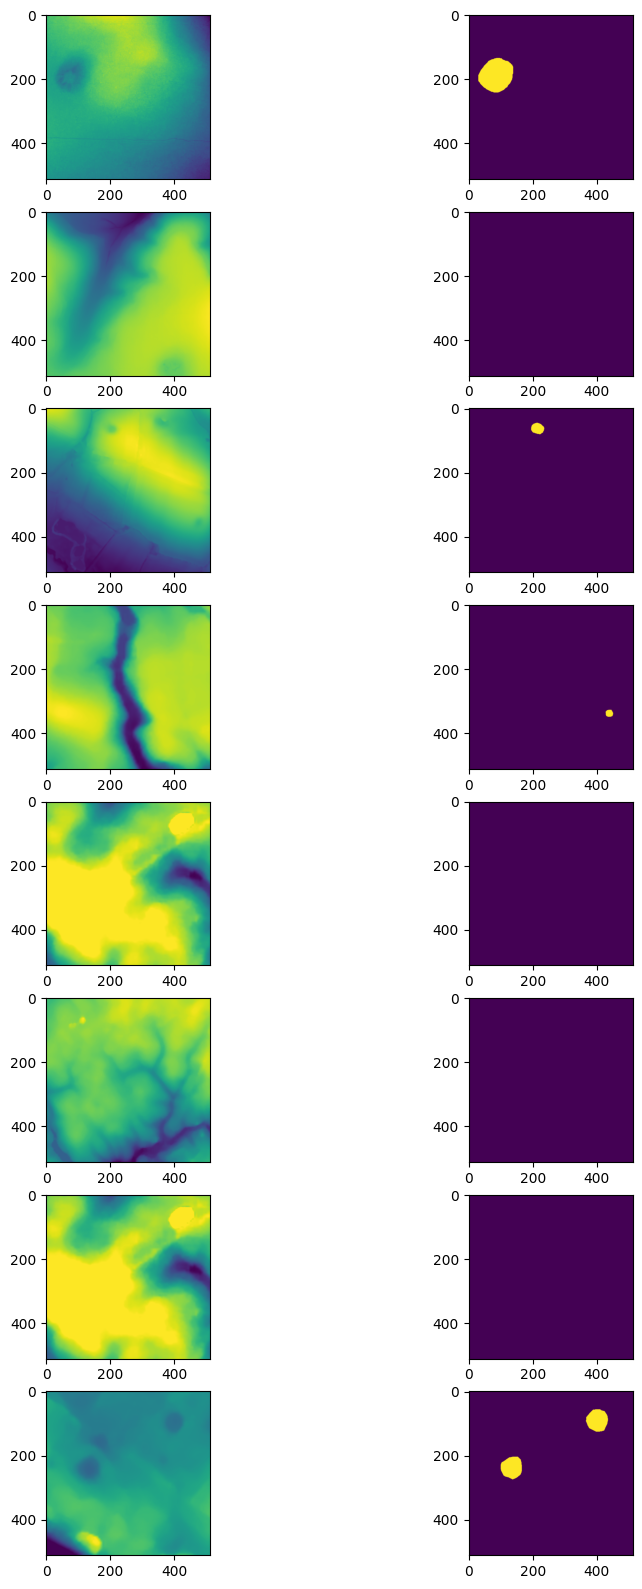

In [ ]:
images, masks = next(iter(train_loader))

fig, axes = plt.subplots(8, 2, figsize=(10, 20))

for i, (image, mask) in enumerate(zip(images, masks)):
  axes[i, 0].imshow(image[0])
  axes[i, 1].imshow(mask)

# UNET


In [ ]:
from scipy.ndimage import label, center_of_mass

def object_centroid_metrics(pred_mask, gt_mask):
    """
    A prediction is counted as a true positive if the centroid of a predicted object
    falls inside an unmatched ground-truth object.
    """

    pred_labels, n_pred = label(pred_mask > 0)
    gt_labels, n_gt = label(gt_mask > 0)

    matched_gt = set()

    tp = 0
    fp = 0

    for pred_id in range(1, n_pred + 1):

        # gets pred_labels[pred_id]
        pred_obj = pred_labels == pred_id

        min_area = 20 # 20 pixel area prediction likely noise
        if pred_obj.sum() < min_area:
          continue

        # centroid of predicted blob
        cy, cx = center_of_mass(pred_obj)

        if np.isnan(cx) or np.isnan(cy):
            continue

        r = int(round(cy))
        c = int(round(cx))

        # ensure inside image
        r = np.clip(r, 0, gt_mask.shape[0] - 1)
        c = np.clip(c, 0, gt_mask.shape[1] - 1)

        gt_id = gt_labels[r, c]

        if gt_id == 0:
            fp += 1
            continue

        # already matched
        if gt_id in matched_gt:
            fp += 1
            continue

        matched_gt.add(gt_id)
        tp += 1

    fn = n_gt - tp

    if tp + fp == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)

    if tp + fn == 0:
        recall = 0.0
    else:
        recall = tp / (tp + fn)

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return tp, fp, fn, precision, recall, f1

In [ ]:
class TVLoss(nn.Module):
    """
    Total Variation loss penalises pixel roughness in the predicted
    probability map.

    Operates on sigmoid probabilities (not logits) so the gradient signal is
    tied to the actual output shape rather than unbounded logit values.
    """

    def __init__(self, weight: float = 1e-2):
        super().__init__()
        self.weight = weight

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        diff_h = (probs[:, :, 1:, :] - probs[:, :, :-1, :]).abs().mean()
        diff_w = (probs[:, :, :, 1:] - probs[:, :, :, :-1]).abs().mean()
        return self.weight * (diff_h + diff_w)

class DiceLoss(nn.Module):
    """Soft Dice, optimises foreground overlap (IoU-type loss)"""
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        return 1 - (2 * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

class CombinedLoss(nn.Module):
    """
    BCE + Dice + TV loss.

    alpha -> weight on dice
    pos_weight -> weighting on positive class in BCE
    tv_weight -> multiplier for tv loss
    """

    def __init__(
        self,
        alpha = 0.6,
        pos_weight = 5.0,
        tv_weight = 5e-3,
    ):
        super().__init__()
        self.alpha = alpha
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
        self.tv = TVLoss(weight=tv_weight)

    def forward(self, logits, targets):

        return (self.alpha * self.dice(logits, targets) + (1 - self.alpha) * self.bce(logits, targets)
            + self.tv(logits))


In [ ]:
class DoubleConv(nn.Module):
    """unet base block.

    conv2d, relu, batchnorm.
    """

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

# learns which channels are important
# need to understand what this is actually doing mathematically.
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(self.avg(x).squeeze(-1).squeeze(-1))
        return x * w.unsqueeze(-1).unsqueeze(-1)


# encoder block
class Down(nn.Module):
    """MaxPool (downsamples image) followed by DoubleConv (increase channels), one encoder step."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch),
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    """(upsamples image), concatenate skip (for retaining fine spatial detail),
     DoubleConv (decrease channels), one decoder step.
     """

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        # in_ch comes from (upsampled features + skip features)
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        # Pad if the skip tensor is slightly larger (odd input dimensions)
        if x.shape != skip.shape:
            x = F.pad(x, [0, skip.shape[-1] - x.shape[-1],
                           0, skip.shape[-2] - x.shape[-2]])

        x = torch.cat([skip, x], dim=1)   # channel-wise concat
        return self.conv(x)

# sort of a feature pyramid, uses dilations to view bottleneck at different scales.
class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, dilations=(1, 3, 6, 12)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ) for d in dilations
        ])
        self.project = nn.Conv2d(out_ch * len(dilations), out_ch, 1, bias=False)

    def forward(self, x):
        return self.project(torch.cat([b(x) for b in self.branches], dim=1))

# combined
class UNet(nn.Module):
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()
        f = base_filters

        # Encoder
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = Down(f, f * 2)
        self.enc3 = Down(f * 2, f * 4)
        self.enc4 = Down(f * 4, f * 8)

        # Bottleneck, pool down then ASPP for *some* scale invariance
        self.pool = nn.MaxPool2d(2)
        self.aspp = ASPP(f * 8, f * 16)
        self.bottleneck_attn = ChannelAttention(f * 16)
        self.bottleneck_drop = nn.Dropout2d(p=0.2)

        # Decoder
        self.dec4 = Up(f * 16 + f * 8, f * 8)
        self.dec3 = Up(f * 8 + f * 4, f * 4)
        self.dec2 = Up(f * 4 + f * 2, f * 2)
        self.dec1 = Up(f * 2 + f, f)

        self.out_conv = nn.Conv2d(f, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)

        # bottleneck
        b = self.pool(s4)
        b = self.bottleneck_drop(b) # dropout
        b = self.aspp(b) # sees several scales
        b = self.bottleneck_attn(b) # what channels are important?

        x = self.dec4(b, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return self.out_conv(x)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=5, base_filters=64).to(device)
criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 150
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-5
)

# unique checkpointing to save best model
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M')  # e.g. 20250626_1432
CHECKPOINT_DIR = Path(f'/content/drive/MyDrive/IRP/models/checkpoints/{RUN_ID}')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# initialise metrics
vls, tls, ious, accs, precisions, recalls, f1s = [], [], [], [], [], [], []
best_iou = 0.0
obj_precisions, obj_recalls, obj_f1s = [], [], []

for epoch in range(EPOCHS):

    # Train
    model.train()

    # epoch level loss
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        logits = model(images)

        # BCE + DICE + TV loss
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()

    # init epoch level val metrics
    iou_tp = iou_fp = iou_fn = correct = total = intersection = union = tp = fp = fn = val_loss = 0.0


    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device).unsqueeze(1).float()

            logits = model(images)
            val_loss += criterion(logits, masks).item()

            # threshold at 0.75, from precision-recall curve
            preds = (torch.sigmoid(logits) >= 0.75).float()

            # object metrics
            pred_np = preds.cpu().numpy()
            mask_np = masks.cpu().numpy()

            # is centroid of prediction in ground truth label for that object?
            for i in range(pred_np.shape[0]):
                iou_tp_i, iou_fp_i, iou_fn_i, _, _, _ = object_centroid_metrics(
                    pred_np[i, 0],
                    mask_np[i, 0]
                )
                iou_tp += iou_tp_i
                iou_fp += iou_fp_i
                iou_fn += iou_fn_i

            correct += (preds == masks).sum().item()
            total += masks.numel()
            intersection += (preds * masks).sum().item()
            union += (preds + masks - preds * masks).sum().item()
            tp += (preds * masks).sum().item()
            fp += (preds * (1 - masks)).sum().item()
            fn += ((1 - preds) * masks).sum().item()

    scheduler.step()

    # metrics

    iou_precision = (iou_tp + 1e-6) / (iou_tp + iou_fp + 1e-6)
    iou_recall = (iou_tp + 1e-6) / (iou_tp + iou_fn + 1e-6)
    iou_f1 = 2 * iou_precision * iou_recall / (iou_precision + iou_recall + 1e-6)

    acc = 100 * correct / total
    iou = (intersection + 1e-6) / (union + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)

    vls.append(avg_val)
    tls.append(avg_train)
    ious.append(iou)
    accs.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    obj_precisions.append(iou_precision)
    obj_recalls.append(iou_recall)
    obj_f1s.append(iou_f1)

    # checkpointing
    if iou > best_iou:
        best_iou = iou

        for old in CHECKPOINT_DIR.glob('best_*.pt'):
            old.unlink()

        torch.save(model.state_dict, CHECKPOINT_DIR / f'best_epoch{epoch+1:03d}_iou{iou:.4f}.pt')
        print(f'Best checkpoint saved (iou {iou:.4f})')

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"train {avg_train:.4f} | "
          f"val {avg_val:.4f} | "
          f"acc {acc:.2f}% | "
          f"iou {iou:.4f} | "
          f"P {precision:.4f} | "
          f"R {recall:.4f} | "
          f"F1 {f1:.4f} | "
          f"Obj_P {iou_precision:.4f} | "
          f"Obj_R {iou_recall:.4f} | "
          f"Obj_F1 {iou_f1:.4f} | ")

Best checkpoint saved (iou 0.0000)
Epoch   1/75 | train 0.8388 | val 0.8797 | acc 96.76% | iou 0.0000 | P 1.0000 | R 0.0000 | F1 0.0000 | Obj_P 1.0000 | Obj_R 0.0000 | Obj_F1 0.0000 | 
Epoch   2/75 | train 0.7969 | val 0.8357 | acc 96.76% | iou 0.0000 | P 1.0000 | R 0.0000 | F1 0.0000 | Obj_P 1.0000 | Obj_R 0.0000 | Obj_F1 0.0000 | 
Best checkpoint saved (iou 0.0574)
Epoch   3/75 | train 0.7922 | val 0.8168 | acc 96.18% | iou 0.0574 | P 0.2224 | R 0.0718 | F1 0.1085 | Obj_P 0.1923 | Obj_R 0.0980 | Obj_F1 0.1299 | 
Epoch   4/75 | train 0.7640 | val 0.7993 | acc 95.93% | iou 0.0313 | P 0.1200 | R 0.0406 | F1 0.0606 | Obj_P 0.2857 | Obj_R 0.0784 | Obj_F1 0.1231 | 
Best checkpoint saved (iou 0.0628)
Epoch   5/75 | train 0.7707 | val 0.8542 | acc 95.38% | iou 0.0628 | P 0.1546 | R 0.0956 | F1 0.1182 | Obj_P 0.1852 | Obj_R 0.0980 | Obj_F1 0.1282 | 
Epoch   6/75 | train 0.7529 | val 0.8411 | acc 92.87% | iou 0.0534 | P 0.0857 | R 0.1242 | F1 0.1014 | Obj_P 0.1250 | Obj_R 0.0784 | Obj_F1 0.096

Val set size: 21 — TILE_IDX can be 0 to 17
Pixel TP 9870  FP 7493  FN 29606
Pixel Precision 0.568  Recall 0.250
Tile 4: IoU 0.000
Tile 5: IoU 0.468
Tile 6: IoU 0.000
Tile 7: IoU 0.000


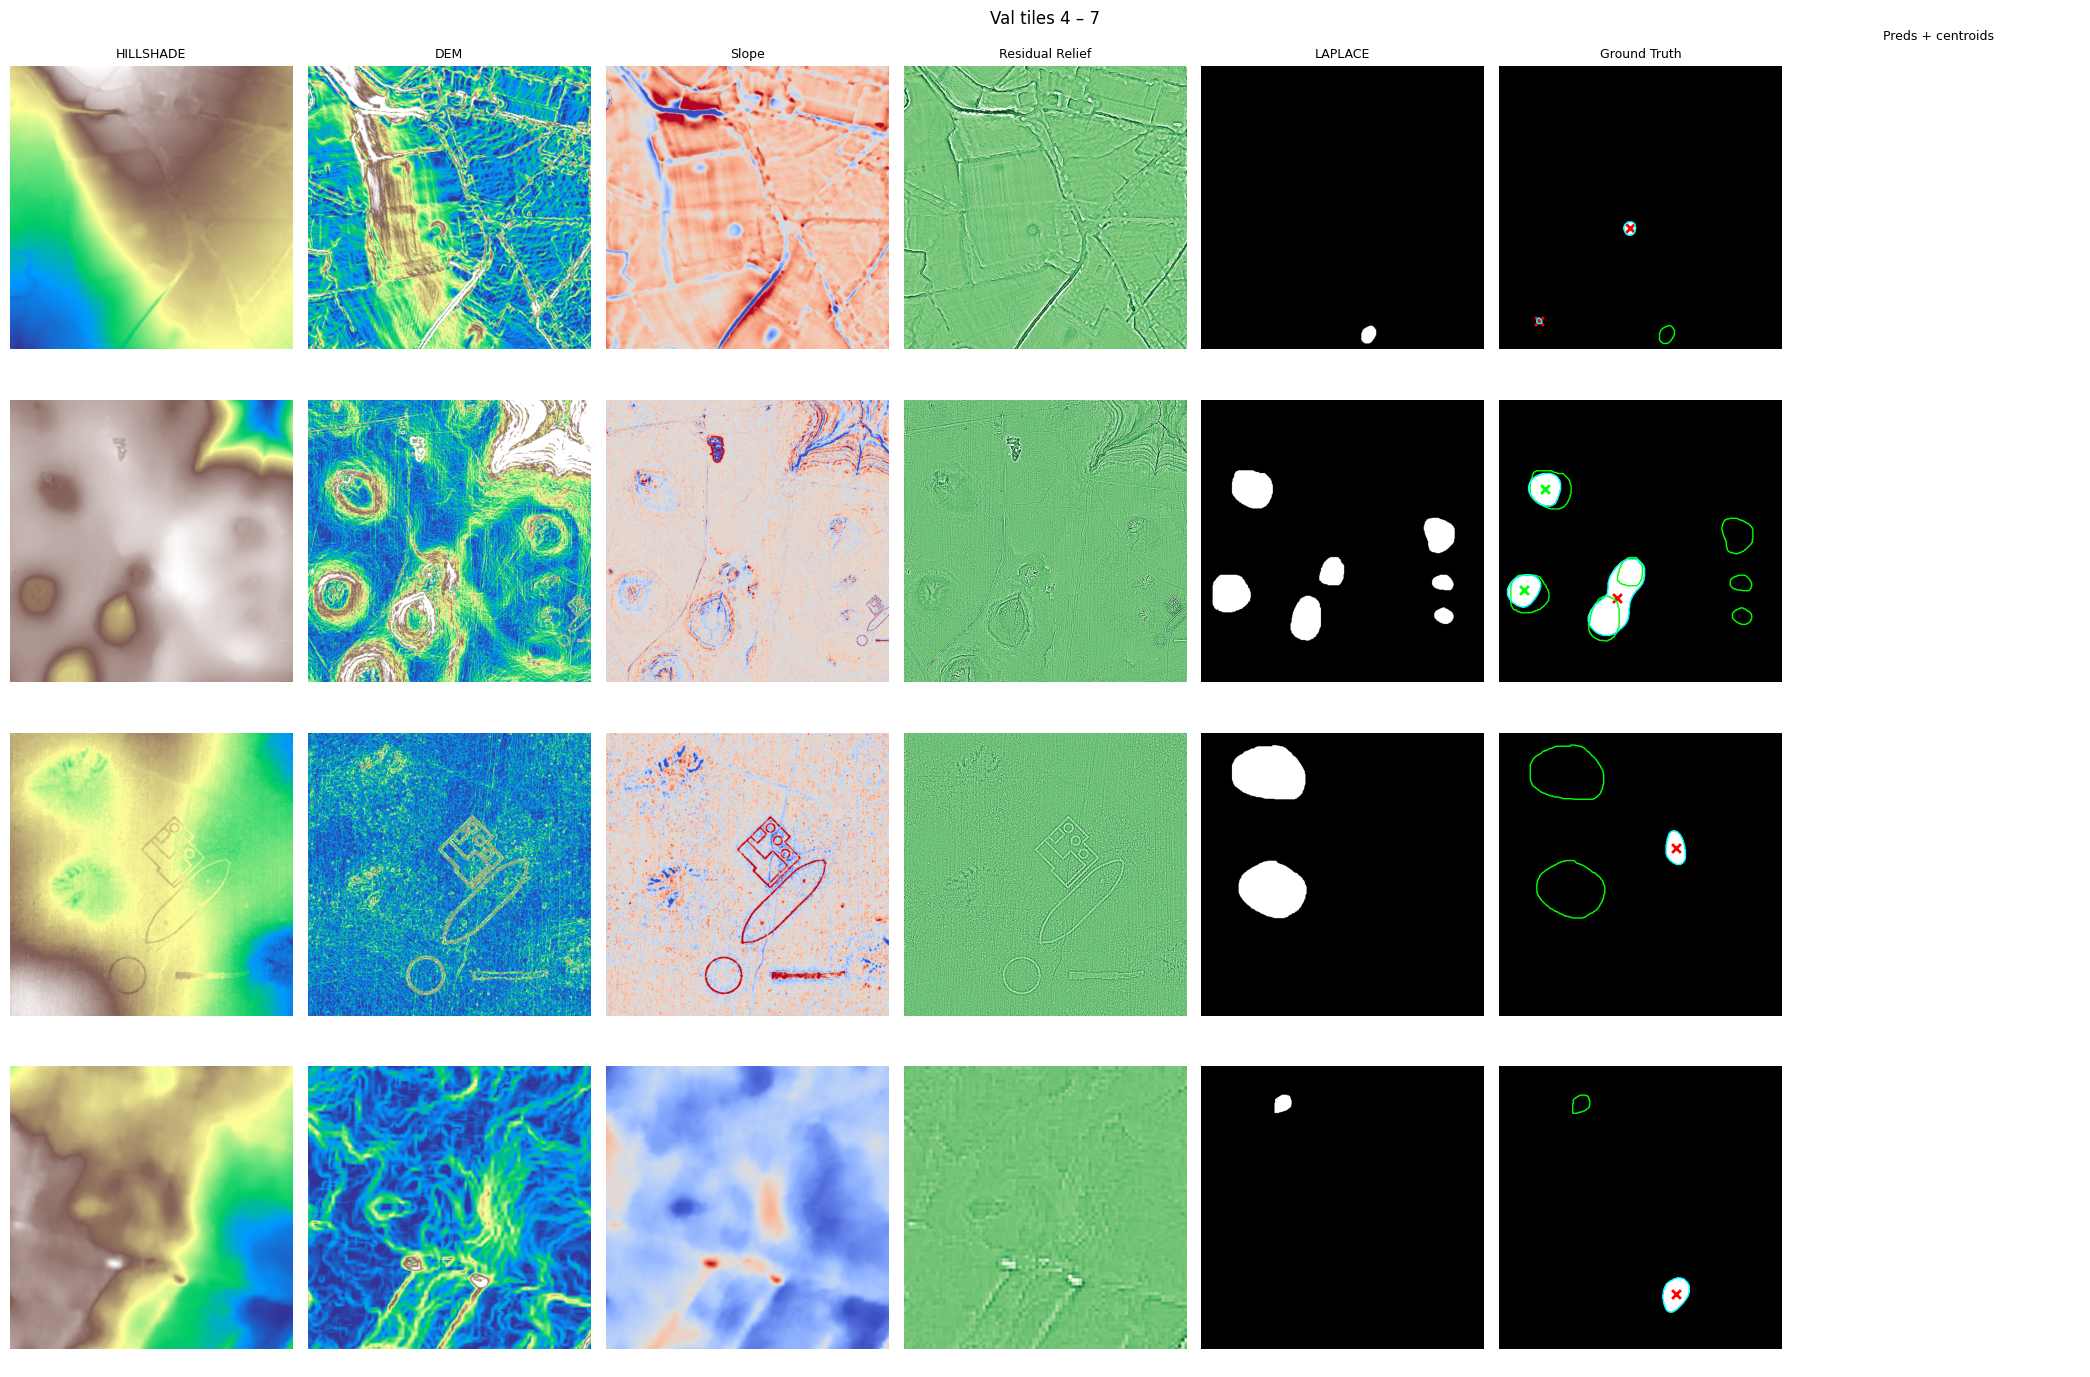

In [ ]:
from scipy.ndimage import label, center_of_mass

# AI assistance with this plotting function
def pred_centroids_for_plot(pred_mask, gt_mask, min_pred_area=20):
    pred_labels, n_pred = label(pred_mask > 0)
    gt_labels, _ = label(gt_mask > 0)

    points = []

    for pred_id in range(1, n_pred + 1):
        pred_obj = pred_labels == pred_id

        if pred_obj.sum() < min_pred_area:
            continue

        cy, cx = center_of_mass(pred_obj)

        if np.isnan(cx) or np.isnan(cy):
            continue

        r = int(round(cy))
        c = int(round(cx))

        r = np.clip(r, 0, gt_mask.shape[0] - 1)
        c = np.clip(c, 0, gt_mask.shape[1] - 1)

        detected = gt_labels[r, c] > 0
        points.append((cx, cy, detected))

    return points


val_set = val_loader.dataset

# choose tile index here
TILE_IDX = 4

imgs, msks = zip(*[val_set[i] for i in range(TILE_IDX, TILE_IDX + 4)])
images = torch.stack(imgs).to(device)
masks = torch.stack(msks).unsqueeze(1).float().to(device)

with torch.no_grad():
    out = model(images)

    probs = torch.sigmoid(logits)
    preds = (probs > 0.75).float()

    tp = (preds * masks).sum()
    fp = (preds * (1 - masks)).sum()
    fn = ((1 - preds) * masks).sum()

    print(f"Pixel TP {tp:.0f}  FP {fp:.0f}  FN {fn:.0f}")
    print(f"Pixel Precision {tp/(tp+fp+1e-6):.3f}  Recall {tp/(tp+fn+1e-6):.3f}")

    for i in range(4):
        p, m = preds[i], masks[i]
        intersection = (p * m).sum()
        union = (p + m).clamp(max=1).sum()
        iou = (intersection / (union + 1e-6)).item()
        print(f"Tile {TILE_IDX + i}: IoU {iou:.3f}")

cols = [
    'HILLSHADE',
    'DEM',
    'Slope',
    'Residual Relief',
    'LAPLACE',
    'Ground Truth',
    'Preds + centroids'
]

n_cols = len(cols)

fig, axes = plt.subplots(4, n_cols, figsize=(n_cols * 3, 14))

for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=9)

for i in range(4):
    img = images[i].cpu().numpy()
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img[0], cmap='terrain')
    axes[i, 1].imshow(img[0], cmap='terrain')
    axes[i, 2].imshow(img[1], cmap='terrain')
    axes[i, 3].imshow(img[2], cmap='coolwarm')
    axes[i, 4].imshow(img[3], cmap='Greens')
    axes[i, 5].imshow(gt, cmap='gray', vmin=0, vmax=1)

    axes[i, 6].imshow(pred, cmap='gray', vmin=0, vmax=1)

    # GT outline
    axes[i, 6].contour(gt, levels=[0.5], colors='lime', linewidths=1)

    # Predicted object outline
    axes[i, 6].contour(pred, levels=[0.5], colors='cyan', linewidths=1)

    points = pred_centroids_for_plot(pred, gt, min_pred_area=20)

    # green or red for predictrion success (TP, FP)
    for cx, cy, detected in points:
        colour = 'lime' if detected else 'red'
        axes[i, 5].scatter(cx, cy, c=colour, s=40, marker='x', linewidths=2)

    for j in range(n_cols):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# precision recall curve and threshold reporting

all_probs, all_labels = [], []

# get predictions
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        probs  = torch.sigmoid(model(images.to(device))).cpu().numpy().ravel()
        labels = masks.numpy().ravel()
        all_probs.append(probs)
        all_labels.append(labels)

probs  = np.concatenate(all_probs)
labels = np.concatenate(all_labels)

# use sklearn (from deep learning material!)
precision, recall, thresholds = precision_recall_curve(labels, probs)

# Find threshold at a few precision targets
for target_p in [0.5, 0.6, 0.70, 0.75, 0.80, 0.85]:
    idx = np.where(precision >= target_p)[0]
    if len(idx):
        i = idx[0]
        print(f"P≥{target_p:.0%}, threshold {thresholds[i]:.3f}  recall {recall[i]:.3f}  F1 {2*precision[i]*recall[i]/(precision[i]+recall[i]):.3f}")

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR curve')
plt.grid(True)
plt.show()

In [ ]:
epochs = range(1, len(tls) + 1)

# inefficient but does the job!
# plotting learning curves for understanding model performanc
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].plot(epochs, tls, label='train')
axes[0, 0].plot(epochs, vls, label='val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()

axes[0, 1].plot(epochs, ious)
axes[0, 1].set_title('IoU')
axes[0, 1].set_ylim(0, 1)

axes[0, 2].plot(epochs, accs)
axes[0, 2].set_title('Accuracy')
axes[0, 2].set_ylim(0, 100)

axes[1, 0].plot(epochs, precisions)
axes[1, 0].set_title('Precision')
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(epochs, recalls)
axes[1, 1].set_title('Recall')
axes[1, 1].set_ylim(0, 1)

axes[1, 2].plot(epochs, f1s)
axes[1, 2].set_title('F1')
axes[1, 2].set_ylim(0, 1)

for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()